# Sales Prediction Using Python

## Objective

### The Objective Of this Project is to Build a Machine Learning Regression Model That Predicts Product Sales Based On Advertising Expenditure Across Different Media Channels.

 ### The Project Analyzes The Relationship Between:

#### - TV Advertising
#### - Radio Advertising
#### - Newspaper Advertising

### And the Target variable:

#### - Sales

 ### Tools And Technologies

#### - Jupyter Notebook
#### - Matplotlib
#### - NumPy
#### - Pandas
#### - Python
#### - Scikit-Learn
#### - Seaborn 


### Step 1 — Import Libraries

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Step 2 — Load Dataset

In [4]:
df = pd.read_csv("Advertising.csv")

In [5]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Step 3 — Data Understanding And Cleaning

#### Data Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


#### Dataset Shape

In [7]:
df.shape

(200, 5)

#### Missing Values

In [8]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

#### Duplicate Values

In [9]:
df.duplicated().sum()

np.int64(0)

#### Descriptive Statistics

In [10]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


#### Remove Unnecessary Column

In [11]:
df = df.drop(columns=["Unnamed: 0"])

In [12]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [13]:
df.shape

(200, 4)

### Step 4 — Exploratory Data Analysis

#### Correlation Matrix

In [14]:
df.corr(numeric_only=True)

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


#### Correlation With Sales

In [15]:
df.corr(numeric_only=True)["Sales"].sort_values(ascending=False)

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64

### Step 5 — Data Visualization

### Pairplot

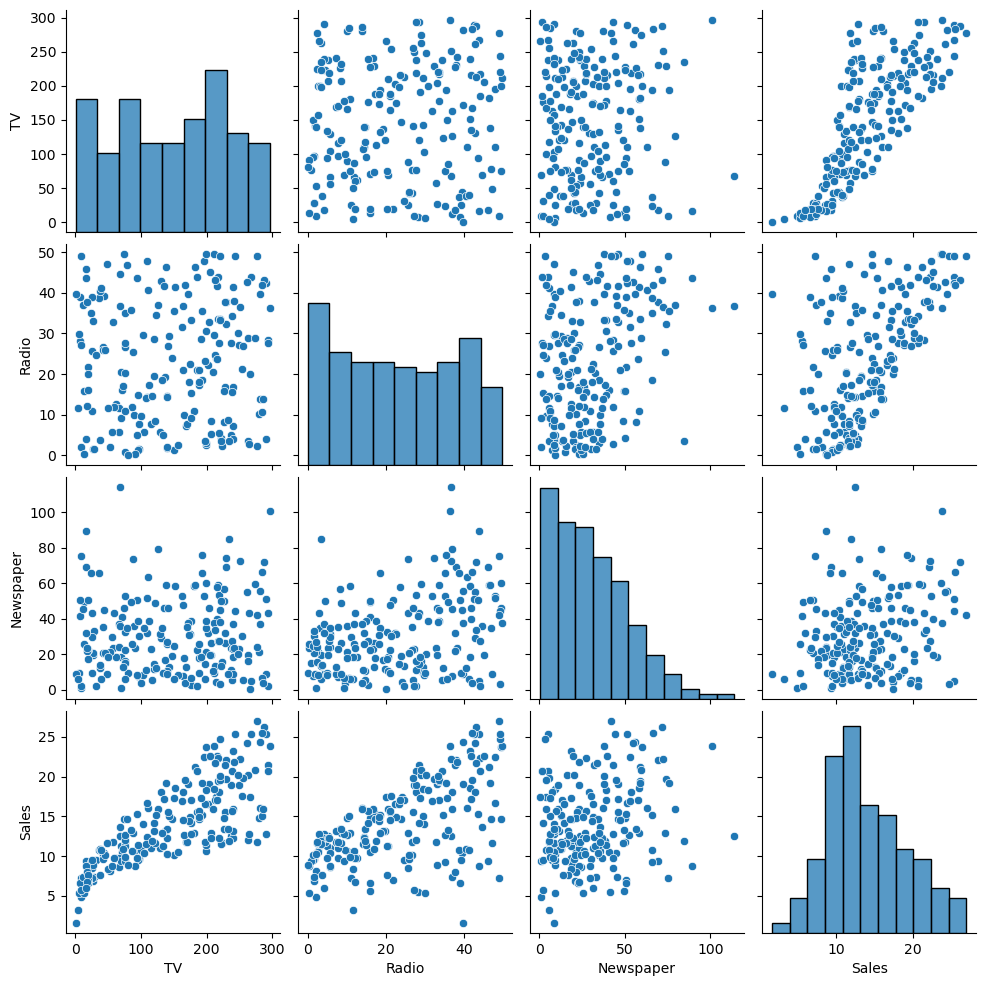

In [16]:
sns.pairplot(df)
plt.show()

### Advertising Channels vs Sales

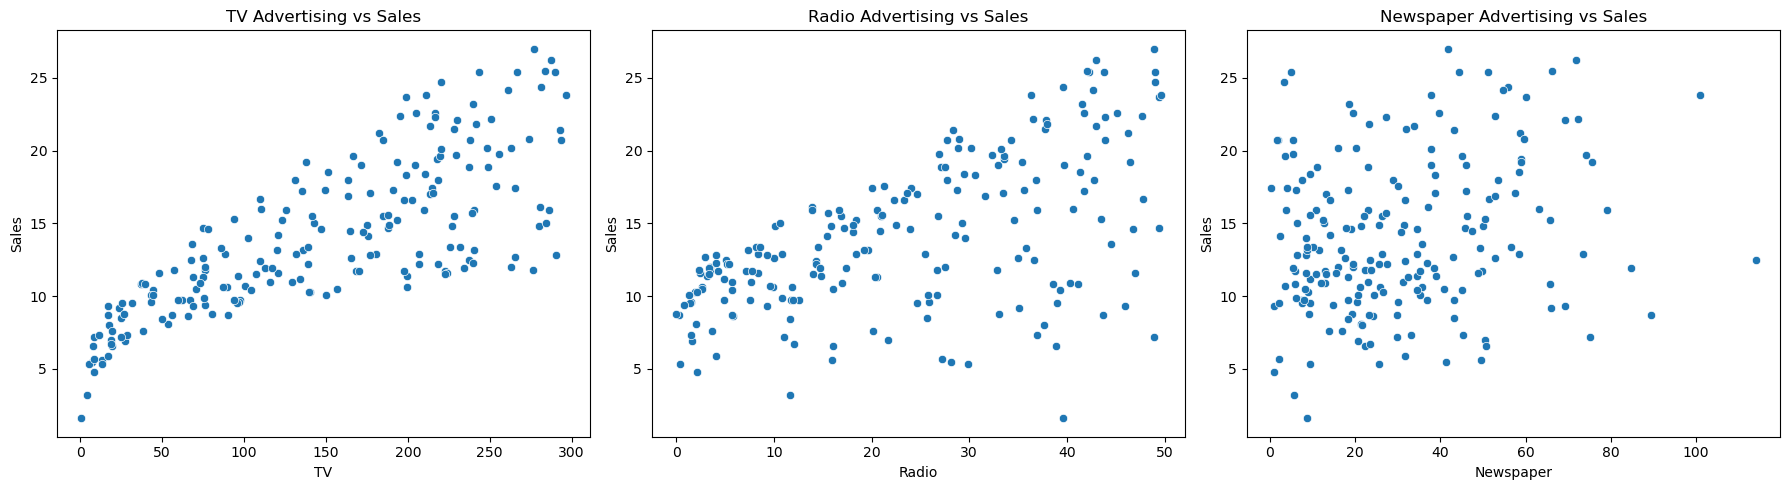

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="TV", y="Sales", ax=axes[0])
axes[0].set_title("TV Advertising vs Sales")

sns.scatterplot(data=df, x="Radio", y="Sales", ax=axes[1])
axes[1].set_title("Radio Advertising vs Sales")

sns.scatterplot(data=df, x="Newspaper", y="Sales", ax=axes[2])
axes[2].set_title("Newspaper Advertising vs Sales")

plt.tight_layout()
plt.show()

### Correlation Heatmap

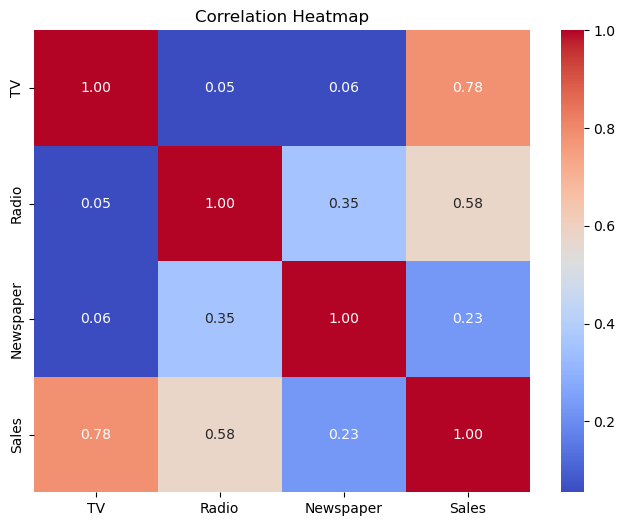

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

### Step 6 — Feature Selection

### Define Features And Target

In [19]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

### Check Features

In [20]:
display(X.head())

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


### Check Target

In [21]:
display(y.head())

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

### Step 7 — Train-Test Split

### Import Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

### Split Dataset

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Check Split

In [24]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (160, 3)
Testing Data: (40, 3)


### Step 8 — Model Training

### (1) Import Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

### Create Model

In [26]:
model = LinearRegression()

### Train Model

In [27]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Make Predictions

In [28]:
y_pred = model.predict(X_test)

### Step 9 — Model Evaluation And Prediction

### Import Evaluation Metrics

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Calculate Evaluation Metrics

In [30]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.4607567168117606
Root Mean Squared Error (RMSE): 1.7815996615334502
R² Score: 0.899438024100912


### Display Actual And Predicted Sales

In [31]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

display(results.head(10))

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


### Actual vs Predicted Visualization

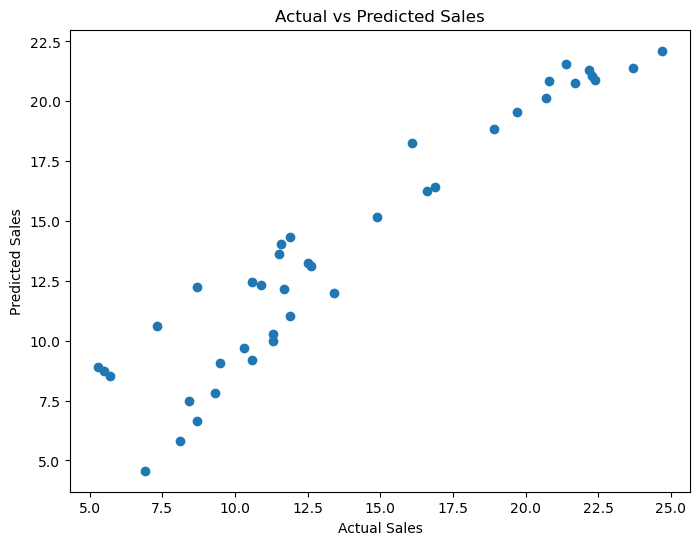

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

### Model Training

### (2) Import Random Forest Regressor

In [35]:
from sklearn.ensemble import RandomForestRegressor

### Create Random Forest Model

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

### Train Random Forest Model

In [37]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Make Predictions

In [38]:
rf_pred = rf_model.predict(X_test)

### Model Evaluation And Prediction

### Random Forest Evaluation

In [39]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 0.6200999999999988
Random Forest RMSE: 0.7685910811348248
Random Forest R² Score: 0.9812843792541843


### Random Forest — Actual Vs Predicted

In [40]:
rf_results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": rf_pred
})

display(rf_results.head(10))

,Actual Sales,Predicted Sales
0,16.9,17.698
1,22.4,21.804
2,21.4,20.628
3,7.3,6.793
4,24.7,22.927
5,12.6,13.379
6,22.3,22.376
7,8.4,9.688
8,11.5,11.826
9,14.9,15.540


### Actual vs Predicted Visualization

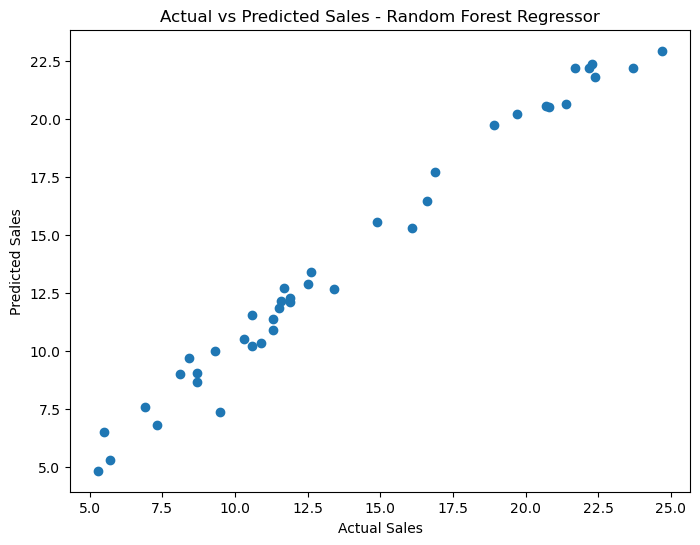

In [41]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Random Forest Regressor")

plt.show()

### Step 10 -Residual Plot For Best Model

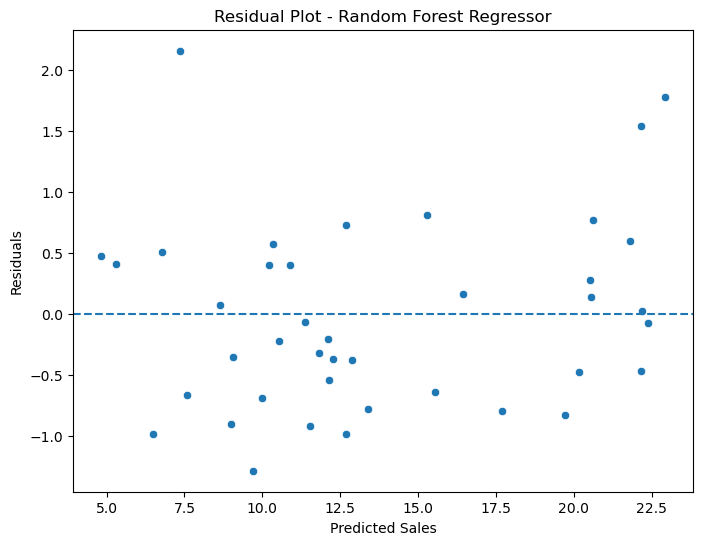

In [42]:
residuals = y_test - rf_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(x=rf_pred, y=residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest Regressor")

plt.show()

### Step 11 — Feature Importance

### Calculate Feature Importance

In [43]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


### Feature Importance Plot

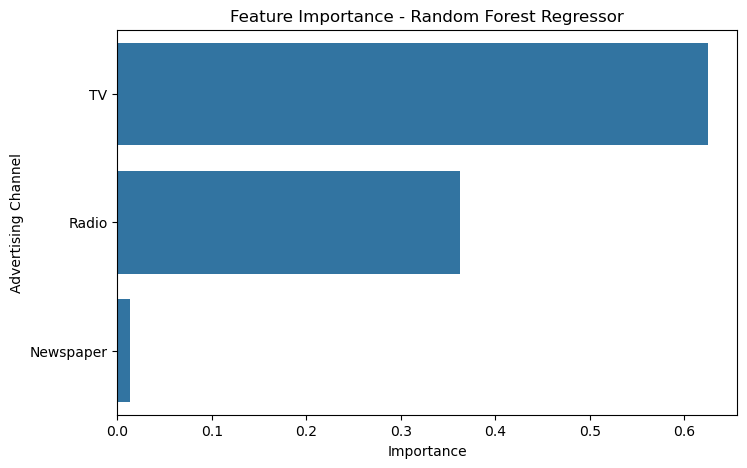

In [44]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance - Random Forest Regressor")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

## Interpretation

### According to the Random Forest Feature Importance Analysis, TV Advertising Has The Highest Impact On Sales, With An Importance score of 0.624810.

### Radio is the Second Most Important Feature, With An Importance Score Of 0.362201, While Newspaper Has The Lowest Importance At 0.012989.

### Therefore, TV Advertising Appears To Be The Most Influential Advertising Channel For Predicting Product Sales in This Dataset.

## Step 12 — Conclusion


### The Sales Prediction Project Successfully Demonstrates How Machine Learning Can Be Used To Predict Product Sales Based On Advertising Expenditure Across TV, Radio, and Newspaper Channels.

### Two Regression Models Were Trained And Evaluated: Linear Regression and Random Forest Regressor. The Random Forest Regressor Performed Better, Achieving an R² score of 98.13%, with an MAE of 0.62 And An RMSE of 0.77.

### Feature Importance Analysis Showed That TV Advertising Had The Highest Impact On Sales, Followed By Radio, While Newspaper Had The Lowest Impact.

### Overall, the Random Forest Regressor Provided Strong Predictive Performance and Was Selected As The Best Model For This Sales Prediction Task.